# How well do jobs and skills pay for Top 5 roles in SEA?

## Methodology
1. Evaluate median salary for top 5 jobs
2. Find median salary per skill for top 5 jobs
3. Visualize for highest paying skills and most demanded skills

## Import Libraries and Dataset

In [2]:
#Turn off warning notification
import warnings
warnings.filterwarnings("ignore")

import datasets
datasets.logging.set_verbosity_error()

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter

#Load dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df.job_posted_date = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## Salary Distribution by Job Title

Filter our data to only include salary values from Southeast Asia.

In [4]:
# Countries belong to Southeast Asia
countries = ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia' , 'Myanmar'
             , 'Philippines', 'Singapore', 'Thailand', 'East Timor', 'Vietnam']

In [ ]:
# Skill count per month for top 5 jobs
df_SEA = df[(df['job_country'].isin(countries))].copy()

# Calculating the median salary
median_salary = df_SEA['salary_year_avg'].median()

# Filling the missing values with the median salary to keep the DataFrame intact
df_SEA['salary_year_avg'] = df_SEA['salary_year_avg'].fillna(median_salary)

Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [43]:
job_titles = df_SEA['job_title_short'].value_counts().head(5).index

# Filter the df for top 5 job title:
df_SEA_top5 = df_SEA[df_SEA['job_title_short'].isin(job_titles)]

# Order the job titles by median salary:
job_order = df_SEA_top5.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=False).index

job_order 

Index(['Data Engineer', 'Data Scientist', 'Data Analyst', 'Business Analyst',
       'Software Engineer'],
      dtype='str', name='job_title_short')

## Plot Salary Distributions

Plot the top 5 job titles salary distributions using a box plot.

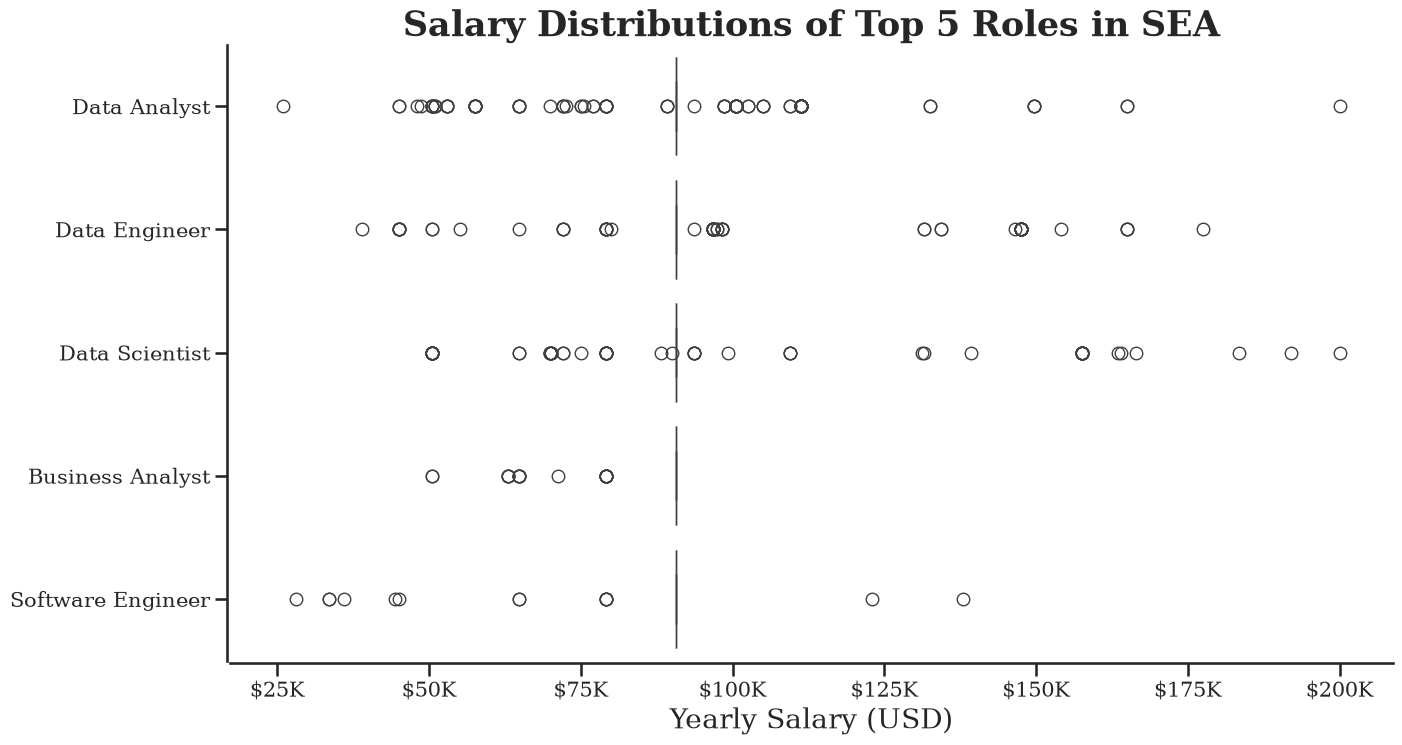

In [55]:
fig, ax = plt.subplots(figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'tab10'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

sns.boxplot(
            data=df_SEA
            , y = 'job_title_short'
            , x = 'salary_year_avg'
            , order = job_titles)

sns.despine(offset=2)

plt.title(
            'Salary Distributions of Top 5 Roles in SEA'
            , fontdict={'fontsize': 25, 'fontweight': 'bold'})

plt.xlabel(
            'Yearly Salary (USD)'
            , fontdict={'fontsize': 20})

plt.ylabel(
            ''
            , fontdict={'fontsize': 20})

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000):,}K'))
plt.gca().tick_params(axis='x', labelsize = 15)
plt.gca().tick_params(axis='y', labelsize = 15)

plt.show()